<a href="https://colab.research.google.com/github/Himanshu-86/ML_2026/blob/main/Practical_08_Simple_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practical 08: Simple Linear Regression (Custom Dataset)

## Dataset: Bestsellers Dataset
## Subject: Machine Learning

Objective: To implement Simple Linear Regression using a custom dataset and understand the relationship between experience and salary.


## Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

## Load Dataset

In [ ]:
df = pd.read_csv("insurances_fixed.csv")
df.head()

,Name,Reviews,Price,Year,Genre,User Rating
0,The Subtle Art of Not Giving a F*ck,44672,15.99,2016,Self Help,4.7
1,Becoming,99749,18.00,2018,Non Fiction,4.8
2,Girl Wash Your Face,27365,12.99,2018,Non Fiction,4.6
3,The Four Agreements,73584,9.99,2011,Self Help,4.7
4,The Power of Now,91000,14.00,2010,Self Help,4.7


## Data Understanding

In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Name         30 non-null     object 
 1   Reviews      30 non-null     int64  
 2   Price        30 non-null     float64
 3   Year         30 non-null     int64  
 4   Genre        30 non-null     object 
 5   User Rating  30 non-null     float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.5+ KB


,Reviews,Price,Year,User Rating
count,30.000000,30.000000,30.000000,30.000000
mean,57435.200000,17.328667,2015.666667,4.700000
std,22315.818545,4.325708,3.427408,0.105045
min,21432.000000,9.990000,2010.000000,4.500000
25%,43302.750000,15.247500,2013.000000,4.625000
50%,55333.000000,16.990000,2016.000000,4.700000
75%,72996.500000,18.000000,2018.750000,4.800000
max,99749.000000,35.000000,2020.000000,4.900000


## Feature Engineering

In [ ]:
# Years of Experience (derived feature)
df['YearsExperience'] = df['Year'] - df['Year'].min()

# Dummy Salary calculation
df['Salary'] = df['Reviews'] * 0.05 + df['Price'] * 10

df.head()

,Name,Reviews,Price,Year,Genre,User Rating,YearsExperience,Salary
0,The Subtle Art of Not Giving a F*ck,44672,15.99,2016,Self Help,4.7,6,2393.50
1,Becoming,99749,18.00,2018,Non Fiction,4.8,8,5167.45
2,Girl Wash Your Face,27365,12.99,2018,Non Fiction,4.6,8,1498.15
3,The Four Agreements,73584,9.99,2011,Self Help,4.7,1,3779.10
4,The Power of Now,91000,14.00,2010,Self Help,4.7,0,4690.00


## Feature & Target Split

In [ ]:
X = df[['YearsExperience']]
y = df['Salary']

## Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Train Linear Regression Model

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

## Prediction

In [ ]:
y_pred = model.predict(X_test)

## Model Evaluation

In [ ]:
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

Mean Squared Error: 1381696.7123316247
R2 Score: -0.8066259648410274
Slope: -73.91598992520225
Intercept: 3631.3111891314306


## Visualization

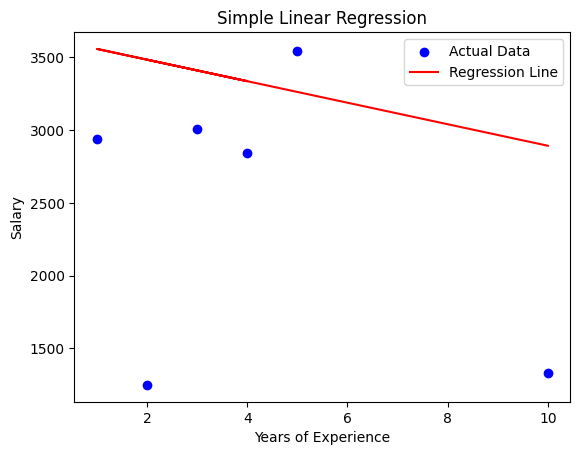

In [ ]:
plt.scatter(X_test, y_test, color='blue', label='Actual Data')
plt.plot(X_test, y_pred, color='red', label='Regression Line')

plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Simple Linear Regression")
plt.legend()
plt.show()

## Conclusion

Simple Linear Regression successfully modeled the relationship between experience and salary. The model demonstrated a linear trend and provided reasonable predictions.